# **ANÁLISIS EXPLORATORIO**

## **Importación de Librerias**

In [1]:
try:
    
    import pandas as pd
    import numpy as np
    import scipy.stats as stats
    import matplotlib.pyplot as plt
    import seaborn as sns
    import missingno as msno
    from sklearn.model_selection import train_test_split, GridSearchCV
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.linear_model import Ridge, Lasso, LogisticRegression
    from sklearn.metrics import classification_report, mean_squared_error, r2_score
    from sklearn.impute import KNNImputer
    from dython.nominal import associations
    from IPython.display import display
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.linear_model import Ridge, Lasso, LogisticRegression
    from sklearn.model_selection import GridSearchCV, train_test_split
    from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve)
    from sklearn.experimental import enable_iterative_imputer
    from sklearn.impute import IterativeImputer, SimpleImputer
    from sklearn.preprocessing import LabelEncoder

    print("Todas las librerías se han importado correctamente. El entorno está listo.")

except ImportError as e:
    print("Error al importar una o más librerías:")
    print(e)



Todas las librerías se han importado correctamente. El entorno está listo.


## **Carga de Datos**

In [2]:
# Cargar datos 
df_Original = pd.read_csv("vehicles.csv")

## **Visión general de los datos**

In [3]:
df = df_Original.copy() #generamos una copia para no modificar los datos originales

Forma del Dataframe

In [ ]:
df.shape

Visualización de Columnas y tipos de datos

In [ ]:
df.dtypes

Visualización de los primeros registros

In [ ]:
df.head(10)

## **Limpieza de nombres de variables**

In [4]:
# Diccionario de traducción: inglés → español

traducciones = {
    "id": "id",
    "url": "enlace",
    "region": "region",
    "region_url": "enlace_region",
    "price": "precio",
    "year": "anio",
    "manufacturer": "fabricante",
    "model": "modelo",
    "condition": "condicion",
    "cylinders": "cilindros",
    "fuel": "combustible",
    "odometer": "odometro",
    "title_status": "estado_titulo",
    "transmission": "transmision",
    "VIN": "numero_vin",
    "drive": "traccion",
    "size": "tamanio",
    "type": "tipo",
    "paint_color": "color_pintura",
    "image_url": "enlace_imagen",
    "description": "descripcion",
    "county": "condado",
    "state": "estado",
    "lat": "lat",
    "long": "long",
    "posting_date": "fecha_publicacion"
}

# Aplicar renombramiento al DataFrame
df.rename(columns=traducciones, inplace=True)


## **Visión de valores faltantes**

Valores faltantes por columna.

In [ ]:
faltantes = df.isnull().sum()
porcentaje_faltantes = (faltantes / len(df)) * 100
faltantes_df = pd.DataFrame({"Nulos": faltantes, "%": porcentaje_faltantes})
faltantes_df.sort_values(by="Nulos", ascending=True)

## **Visualización de duplicados**

Revision de duplicados

In [ ]:
print(f"Duplicados detectados: {df.duplicated().sum()}")

## **Eliminación de Variables irrelevantes**

Se eliminan las variables `tamaño`, `condado` y `cilindros` por su gran porcentaje de datos faltantes, y las demás se descartan porque son irrelevantes en el estudio.


In [5]:
df.drop(columns=['id', 'enlace', 'tamanio', 'enlace_imagen','cilindros', 'enlace_region', 'numero_vin', 'descripcion', 'condado', 'lat', 'long', 'fecha_publicacion'], inplace=True)

## **Visualización de nueva estructura**

In [6]:
# Convertir a categórica
df["anio"] = df["anio"].astype("object")

In [ ]:
df.shape

In [ ]:
df.dtypes

## **Visualizacion de correlación en valores faltantes**

In [ ]:
msno.heatmap(df)



El gráfico muestra cómo se relacionan los **valores faltantes** entre variables del dataset de vehículos.  
Los números representan el grado de **co-ocurrencia** de valores nulos (qué tanto faltan juntos en las mismas filas).  

- La relación más fuerte es entre `color_pintura` y `tipo` (0.5), lo que indica que suelen faltar al mismo tiempo.  
- También destacan `traccion` con `cilindros` (0.4) y `color_pintura` con `cilindros` (0.3).  
- La mayoría de combinaciones muestran valores bajos (<0.2), indicando que los faltantes no se concentran en bloque.  

En conclusión, los faltantes se presentan de forma **parcial y localizada**, principalmente en `color_pintura`, `tipo`, `cilindros` y `traccion`.



In [ ]:
msno.matrix(df)



El gráfico muestra dónde faltan datos en el dataset.  
Las variables con más vacíos son `condicion`, `cilindros`, `traccion`, `tipo` y `color_pintura`.  
En cambio, `region`, `precio`, `anio` y `estado` están casi completos.


## **Visualización de correlación entre variables antes de imputar**

In [ ]:
associations(df, figsize=(12,10))


El gráfico muestra las correlaciones entre variables numéricas y categóricas del dataset.  

- Se observa **alta correlación** entre `region` y `estado` (0.98), lo que indica que aportan información muy similar.  
- También destacan las relaciones entre `modelo` con `anio` (0.94) y con `fabricante` (0.72).  
- `transmision` y `traccion` presentan correlaciones moderadas con `modelo` y `tipo` (0.4–0.6).  
- La variable `precio` casi no se correlaciona con las demás (<0.1), lo que sugiere que depende de múltiples factores y no de una sola variable.  

En general, hay **multicolinealidad** entre variables como `modelo`, `anio` y `fabricante`, mientras que otras como `precio` son más independientes.


# **Imputación de los datos**



| Variable          | % Faltantes | Estrategia                                      |
|-------------------|-------------|-------------------------------------------------|
| id                | 0.000000%   | Eliminar (irrelevante)                          |
| enlace            | 0.000000%   | Eliminar (irrelevante)                          |
| region            | 0.000000%   | Eliminar (irrelevante)                          |
| enlace_region     | 0.000000%   | Eliminar (irrelevante)                          |
| precio            | 0.000000%   | Imputar por **mediana** (no normal) despues de eliminar extremos.            |
| estado            | 0.000000%   | Eliminar (irrelevante)                          |
| enlace_imagen     | 0.015930%   | Eliminar (irrelevante)                          |
| fecha_publicacion | 0.015930%   | Eliminar (irrelevante)                          |
| descripcion       | 0.016398%   | Eliminar (irrelevante)                          |
| anio              | 0.282281%   | Imputar por **moda**                            |
| transmision       | 0.598763%   | Imputar por **moda**                            |
| combustible       | 0.705819%   | Imputar por **moda**                            |
| odometro          | 1.030735%   | Imputar por **mediana** (no normal)             |
| modelo            | 1.236179%   | Nueva clase **"Desconocido"**                   |
| lat               | 1.534155%   | Eliminar (irrelevante)                          |
| long              | 1.534155%   | Eliminar (irrelevante)                          |
| estado_titulo     | 1.930753%   | Imputar por **moda**                            |
| fabricante        | 4.133714%   | Nueva clase **"Desconocido"**                   |
| tipo              | 21.752717%  | Imputar por **"Desconocido"**                   |
| color_pintura     | 30.501078%  | Imputar por **moda**                            |
| traccion          | 30.586347%  | Imputar por **moda**                            |
| numero_vin        | 37.725356%  | Eliminar (irrelevante)                          |
| condicion         | 40.785232%  | Nueva clase **"Desconocido"**                   |
| cilindros         | 41.622470%  | Eliminar (>40% faltantes)                          |
| tamanio           | 71.767476%  | Eliminar (>40% faltantes)                       |
| condado           | 100.000000% | Eliminar (>40% faltantes)                       |



## **Variables categóricas**

#### **`fabricante`, `modelo`, `condicion` y `tipo`**

Columnas relevantes y seleccionadas para imputar.

In [ ]:
cat_cols_ = df.select_dtypes(include=['object']).columns.tolist()
print(" Variables categóricas:")
print(cat_cols_)

Cantidad de clases en variables categoricas

In [ ]:
unique_counts = df[cat_cols_].nunique().sort_values(ascending=False)
print(unique_counts)

Imputar con clase nueva `Desconocido`, las variables `fabricante`, `modelo`, `condicion` y `tipo` ya que son variables importantes para el modelo y no queremos distorsionar información.

In [7]:
cols = ['fabricante', 'modelo', 'condicion', 'tipo']

for col in cols:
    # Crear columna indicadora de nulos
    df[f'{col}_es_nulo'] = df[col].isnull().astype(int)
    
    # Reemplazar los nulos por 'desconocido'
    df[col] = df[col].fillna('desconocido')

    print(f"→ {col}: {df[f'{col}_es_nulo'].sum()} valores nulos imputados con 'desconocido'.")


→ fabricante: 17646 valores nulos imputados con 'desconocido'.
→ modelo: 5277 valores nulos imputados con 'desconocido'.
→ condicion: 174104 valores nulos imputados con 'desconocido'.
→ tipo: 92858 valores nulos imputados con 'desconocido'.


## **Variables numéricas**

Variables numericas a visualizar.

In [ ]:
num_cols_ = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("\n Variables numéricas:")
print(num_cols_)

#### **`Odometro`**

Imputar ``odometro``. Como es una variable numérica, revisemos outliers y normalidad.

In [ ]:
data = df['odometro'].dropna()

In [ ]:
sns.boxplot(x=data)
plt.title("Boxplot de 'odometro'")
plt.show()

Este es el diagrama de cajas de la variable representativa del kilometraje, podemos observar presencia de outliers y muy probablemente valores imposibles dentro del contexto.

In [ ]:
# Histograma
plt.figure(figsize=(8,5))
sns.histplot(data, bins=50, kde=True)
plt.title("Distribución de la variable 'odometro'")
plt.show()

In [ ]:
# Q-Q plot
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot para 'odometro'")
plt.show()

La variable `odometro` presenta un alto número de valores extremos que superan ampliamente los rangos coherentes de kilometraje para un vehículo. Estos registros, que alcanzan incluso cifras cercanas a los diez millones, son considerados **valores imposibles** ya que no corresponden a condiciones reales de uso y probablemente se deban a errores de digitación o de registro. 

Mantener estos datos podría distorsionar los análisis estadísticos y los modelos predictivos, generando sesgos en la estimación de tendencias centrales y dispersión. Por esta razón, se opta por tratar los outliers mas adelante.

Para evaluar si la variable `odometro` sigue una distribución normal, se aplican diferentes pruebas estadísticas. En primer lugar, se utiliza el test de **D’Agostino & Pearson**, el cual combina medidas de **asimetría (skewness)** y **curtosis (kurtosis)** para determinar si los datos se desvían significativamente de una distribución normal. Este test es especialmente adecuado en muestras grandes, ya que no está limitado como el test de Shapiro-Wilk.

In [ ]:
# D’Agostino & Pearson
k2, p = stats.normaltest(data)
print("---- D’Agostino & Pearson ----")
print(f"Estadístico: {k2:.3f}, p-valor: {p:.3f}")
print("Interpretación:", "Normal" if p > 0.05 else "No Normal")

Adicionalmente, se emplea el test de **Anderson-Darling**, el cual compara la distribución empírica de los datos contra la distribución normal teórica, asignando mayor peso a las colas. Esto resulta útil en variables como `odometro`, donde suelen presentarse valores extremos. 

In [ ]:
# Anderson-Darling
anderson_result = stats.anderson(data, dist='norm')
print("\n---- Anderson-Darling ----")
print(f"Estadístico: {anderson_result.statistic:.3f}")
for cv, sig in zip(anderson_result.critical_values, anderson_result.significance_level):
    print(f"Nivel de significancia {sig}%: valor crítico {cv:.3f}")
print("Interpretación:",
      "No Normal" if anderson_result.statistic > anderson_result.critical_values[2] else "Normal")

Ambos métodos permiten tener una visión más robusta: mientras que D’Agostino & Pearson analiza la forma general de la distribución, Anderson-Darling es más sensible a los valores en los extremos. En conjunto, ofrecen evidencia suficiente para concluir si la variable se ajusta o no a la normalidad.

#### **`Precio`**

In [ ]:
sns.boxplot(x=df['precio'])
plt.title("Boxplot de 'precio'")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['precio'].dropna(), bins=50, kde=True)
plt.title("Distribución de 'precio'")
plt.show()

In [ ]:
stats.probplot(df['precio'], dist="norm", plot=plt)
plt.title("Q-Q Plot para 'precio'")
plt.show()

La variable `precio` presenta una gran cantidad de valores extremos que no corresponden a precios reales de vehículos. En el análisis exploratorio se identificaron registros con valores cercanos a miles de millones, lo cual es imposible en el contexto del mercado de autos usados. Estos registros son considerados **valores imposibles** y, al igual que en el caso de `odometro`, se opta por tratar los outliers.

# **Generación de variable Binaria `HighDemand`**

Generamos la variable binaria de alta demanda basada en la mediana del precio, pues mas adelante se realiza winsorización de datos atipicos pero esto no afecta significativamente en la formación de la variable.

In [8]:
# Generar variable binaria de alta demanda basada en la mediana del precio
df['HighDemand'] = (df['precio'] > df['precio'].median()).astype(int)

# **Realizamos partición antes de limpiar e imputar con estadísticos para evitar `Data leakage`**

In [9]:
# Separar variables
X = df.drop(columns=['precio', 'HighDemand'])
y_reg = df['precio']
y_clf = df['HighDemand']

In [10]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, stratify=y_clf, random_state=42)

## **Realizamos limpieza de NaNs**

#### ``combustible``, ``estado_titulo``, ``transmision``, ``anio``, ``traccion``,``color_pintura``

Las siguientes variables son importantes pero no principales imputamos por `moda`

In [11]:
# Variables a imputar por moda
cols = ["combustible", "estado_titulo", "transmision", "anio", "traccion","color_pintura"]

cols_moda = df[cols]

# Imputar por moda (valor más frecuente de cada columna)
for col in cols_moda:
    moda_reg = X_train_reg[col].mode()[0]
    moda_clf = X_train_clf[col].mode()[0]   
    X_train_reg[col].fillna(moda_reg, inplace=True)
    X_test_reg[col].fillna(moda_reg, inplace=True)
    X_train_clf[col].fillna(moda_clf, inplace=True)
    X_test_clf[col].fillna(moda_clf, inplace=True)
    
print(moda_reg, moda_clf)

C:\Users\franc\AppData\Local\Temp\ipykernel_9536\3482083034.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_reg[col].fillna(moda_reg, inplace=True)
C:\Users\franc\AppData\Local\Temp\ipykernel_9536\3482083034.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

white white


#### `Odometro`

Imputar faltantes con la mediana por la NO normalidad.

In [12]:
odometro_train_reg = X_train_reg['odometro'].fillna(X_train_reg['odometro'].median()) 
odometro_test_reg = X_test_reg['odometro'].fillna(odometro_train_reg.median())
odometro_train_clf = X_train_clf['odometro'].fillna(X_train_clf['odometro'].median())
odometro_test_clf = X_test_clf['odometro'].fillna(odometro_train_clf.median())

In [13]:
print(odometro_train_reg.isnull().sum())
print(odometro_test_reg.isnull().sum())
print(odometro_train_clf.isnull().sum())    
print(odometro_test_clf.isnull().sum())

0
0
0
0


In [ ]:
sns.boxplot(x=odometro_train_reg)
plt.title("Boxplot de 'odometro'")
plt.show()

La variable `odometro` presentaba una distribución altamente sesgada hacia la derecha, con valores extremos que dificultaban su uso en modelos lineales. Estos algoritmos son sensibles a la presencia de outliers, ya que los valores muy grandes pueden dominar la varianza y afectar negativamente la estimación de los coeficientes.

A continuacion manejamos los datos atipicos con una clase personalizada para **tratar outliers** en un dataset numérico.

Parámetros
- **metodo**:  
  - `"iqr"` → límites con rango intercuartílico (Q1 ± 1.5*IQR).  
  - `"percentil"` → límites en percentiles 1% y 99%.  
- **estrategia**:  
  - `"eliminar"` → descarta filas con outliers.  
  - `"winsorizar"` → recorta valores extremos a los límites.

Flujo
1. `fit()` → calcula límites de outliers para cada columna.  
2. `transform()` → elimina o ajusta los valores fuera de esos límites.  


In [ ]:

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

class ManejoAtipicos(BaseEstimator, TransformerMixin):
    def __init__(self, metodo="iqr", estrategia="winsorizar"):
        
        self.metodo = metodo
        self.estrategia = estrategia
        self.limites_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            if self.metodo == "iqr":
                Q1 = X[col].quantile(0.25)
                Q3 = X[col].quantile(0.75)
                IQR = Q3 - Q1
                lim_inf = Q1 - 1.5 * IQR
                lim_sup = Q3 + 1.5 * IQR
            elif self.metodo == "percentil":
                lim_inf = X[col].quantile(0.01)
                lim_sup = X[col].quantile(0.99)
            else:
                raise ValueError("Método no soportado")
            
            self.limites_[col] = (lim_inf, lim_sup)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            lim_inf, lim_sup = self.limites_[col]
            if self.estrategia == "eliminar":
                X = X[(X[col] >= lim_inf) & (X[col] <= lim_sup)]
            elif self.estrategia == "winsorizar":
                X[col] = np.where(X[col] < lim_inf, lim_inf, X[col])
                X[col] = np.where(X[col] > lim_sup, lim_sup, X[col])
        return X.reset_index(drop=True)




In [15]:
# Instanciar el manejador de atípicos
atipicos_reg = ManejoAtipicos(metodo="iqr", estrategia="winsorizar")

# Ajustar solo con TRAIN
atipicos_reg.fit(odometro_train_reg)

# Transformar TRAIN y TEST
odometro_train_reg_sin_atip = atipicos_reg.transform(odometro_train_reg)
odometro_test_reg_sin_atip  = atipicos_reg.transform(odometro_test_reg)

atipicos_clf = ManejoAtipicos(metodo="iqr", estrategia="winsorizar")

atipicos_clf.fit(odometro_train_clf)
odometro_train_clf_sin_atip = atipicos_clf.transform(odometro_train_clf)
odometro_test_clf_sin_atip  = atipicos_clf.transform(odometro_test_clf)

Hasta este punto se han tratado los outliers de la variable `odometro`, entrenado en train y transformado en ambas.

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(odometro_train_reg_sin_atip, bins=50, kde=True)
plt.title("Distribución de 'odometro' sin atípicos")
plt.show()

In [ ]:
sns.boxplot(x=odometro_train_reg_sin_atip["odometro"])
plt.title("Boxplot de 'odometro'")
plt.show()

Como consecuencia, la distribución se volvió más simétrica y no hay presencia de outliers, lo que mejora la estabilidad y desempeño de los modelos lineales que se construyan.

Asignación respectiva a la variable odometro limpia.

In [16]:
X_test_reg["odometro"] = odometro_test_reg_sin_atip["odometro"].values
X_train_reg["odometro"] = odometro_train_reg_sin_atip["odometro"].values
X_test_clf["odometro"] = odometro_test_clf_sin_atip["odometro"].values
X_train_clf["odometro"] = odometro_train_clf_sin_atip["odometro"].values

## **Visualización de la variable respuesta `Precio`**

Teniendo en cuenta que la variable `precio` no tiene valores faltantes, unicamente se realiza el manejo de outliers.

In [17]:
manejador_precio = ManejoAtipicos(metodo="iqr", estrategia="winsorizar")
y_train_reg_sin_atipicos = manejador_precio.fit_transform(y_train_reg)
y_test_reg_sin_atipicos  = manejador_precio.transform(y_test_reg)
print("Original:", y_train_reg.shape)
print("Sin atípicos:", y_train_reg_sin_atipicos.shape)

Original: (341504,)
Sin atípicos: (341504, 1)


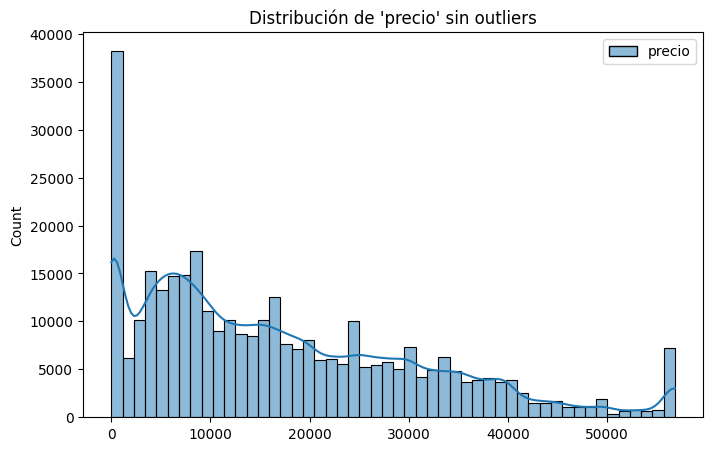

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(y_train_reg_sin_atipicos, bins=50, kde=True)
plt.title("Distribución de 'precio' sin outliers")
plt.show()

La variable **`precio`** despues del manejo de odatos atipicos presenta una distribución **asimétrica positiva**, con mayor concentración en rangos bajos (0–10,000) y una disminución progresiva hacia valores altos. Aún se observan picos intermedios (15,000–20,000) y menor frecuencia en precios superiores a 40,000.

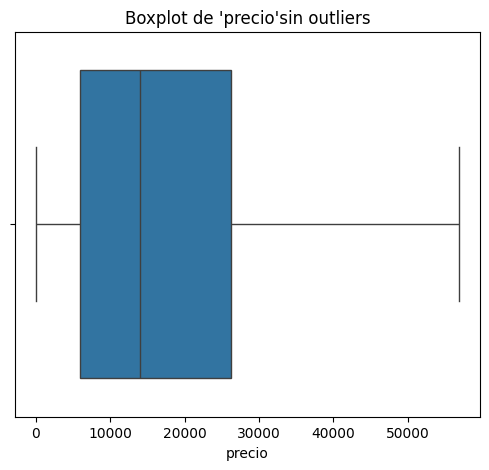

In [35]:
plt.figure(figsize=(6,5))
sns.boxplot(x=y_train_reg_sin_atipicos["precio"])
plt.title("Boxplot de 'precio'sin outliers")
plt.show()

El **boxplot** de `precio` sin outliers muestra que la mayoría de los valores se concentran entre **10,000 y 30,000**, con una mediana cercana a **15,000**. Los bigotes se extienden desde valores bajos hasta precios cercanos a 55,000, reflejando una distribución aún algo dispersa.

Asignacion respectiva.

In [19]:
y_train_reg = y_train_reg_sin_atipicos["precio"]
y_test_reg = y_test_reg_sin_atipicos["precio"]

De esta manera, se asegura que los datos de `precio` utilizados en la modelación reflejen valores bien distribuidos y no estén distorsionados por registros erróneos o poco representativos.

# **Modelado**

Luego de realizar la etapa de limpieza de datos, donde se imputaron los valores faltantes y se trataron los outliers en variables clave como `odometro` y `precio`, los datos se encuentran en una forma más adecuada para la construcción de modelos predictivos. 

En particular, se aplicaron las siguientes transformaciones:
- **Imputación de valores faltantes** 
- **Manejo de outliers**

Con este dataset depurado, se procede a la etapa de **preprocesamiento** que incluye:
- Escalado de variables numéricas con `StandardScaler`.  
- Codificación de variables categóricas mediante `OneHotEncoder`, considerando categorías desconocidas.  
- Integración de todo el flujo en un `ColumnTransformer` dentro de un pipeline de scikit-learn.

Finalmente, sobre este pipeline se entrenarán tres modelos distintos:
1. **Ridge Regression** → modelo lineal regularizado que controla multicolinealidad penalizando los coeficientes grandes.  
2. **Lasso Regression** → modelo lineal regularizado que además puede realizar selección automática de variables al forzar algunos coeficientes a cero.  
3. **Regresión Logística** → modelo de clasificación que se empleará para predecir la variable de demanda (alta o baja) en función de las características del vehículo.  

Con este enfoque se busca comparar el desempeño de modelos lineales de regresión regularizada para predicción de precios, y un modelo de clasificación para la predicción de demanda.

## **Preprocesamiento**

In [20]:
# Columnas por tipo
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()


In [21]:
# Preprocesador: escalado + codificación
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## **Pipelines**

In [ ]:
from sklearn.decomposition import TruncatedSVD

# RIDGE 
ridge_pipe = Pipeline([
    ('prep', preprocessor),
    ('ridge', Ridge())
])
ridge_params = {'ridge__alpha': [0.1, 1, 10]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_params, cv=5)

# PIPELINE LASSO
lasso_pipe = Pipeline([
    ('prep', preprocessor),
    ('svd', TruncatedSVD(n_components=100, random_state=42)), # para reducir dimensionalidad y evitar problemas con Lasso
    ('lasso', Lasso(max_iter=5000, random_state=42))
])
lasso_params = {'lasso__alpha': [0.01, 0.1, 1]}
lasso_grid = GridSearchCV(lasso_pipe, lasso_params, cv=5)

# PIPELINE REGRESIÓN LOGÍSTICA
logreg_pipe = Pipeline([
    ('prep', preprocessor),
    ('logreg', LogisticRegression(max_iter=2000, class_weight='balanced'))
])
logreg_params = {'logreg__C': [0.01, 0.1, 1, 10]}
logreg_grid = GridSearchCV(logreg_pipe, logreg_params, cv=5)



## **Entrenamiento**

In [23]:
ridge_grid.fit(X_train_reg, y_train_reg)

,estimator,"Pipeline(step...e', Ridge())])"
,param_grid,"{'ridge__alpha': [0.1, 1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [29]:
lasso_grid.fit(X_train_reg, y_train_reg)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'lasso__alpha': [0.01, 0.1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [30]:
logreg_grid.fit(X_train_clf, y_train_clf)

,estimator,Pipeline(step..._iter=2000))])
,param_grid,"{'logreg__C': [0.01, 0.1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


## **Selección de mejor modelo**

In [24]:
print("Mejor alpha Ridge:", ridge_grid.best_params_)

Mejor alpha Ridge: {'ridge__alpha': 1}


In [30]:
print("Mejor alpha Lasso:", lasso_grid.best_params_)

Mejor alpha Lasso: {'lasso__alpha': 0.01}


In [31]:
print("Mejor C LogReg:", logreg_grid.best_params_)

Mejor C LogReg: {'logreg__C': 10}


## **Evalución de modelos**

In [ ]:
def evaluar_regresion(modelo, X_test, y_test, nombre_modelo="Modelo"):
    y_pred = modelo.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\nEvaluación del modelo de regresión: {nombre_modelo}")
    print(f"→ MAE:  {mae:.2f}")
    print(f"→ RMSE: {rmse:.2f}")
    print(f"→ R²:   {r2:.3f}")
    
    # Gráfico de valores reales vs predichos
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
    plt.xlabel("Valor real")
    plt.ylabel("Valor predicho")
    plt.title(f"{nombre_modelo}: Real vs. Predicho")
    plt.grid(True)
    plt.show()

def evaluar_clasificacion(modelo, X_test, y_test, nombre_modelo="Modelo"):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"\nEvaluación del modelo de clasificación: {nombre_modelo}")
    print(f"→ Accuracy:  {acc:.3f}")
    print(f"→ Precision: {prec:.3f}")
    print(f"→ Recall:    {rec:.3f}")
    print(f"→ F1-Score:  {f1:.3f}")
    print(f"→ AUC:       {auc:.3f}")
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Prediccion")
    plt.ylabel("Real")
    plt.title(f"{nombre_modelo} - Matriz de Confusión")
    plt.show()

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("Tasa de Falsos Positivos (FPR)")
    plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
    plt.title(f"{nombre_modelo} - Curva ROC")
    plt.legend()
    plt.grid(True)
    plt.show()



📊 Evaluación del modelo de regresión: Modelo
→ MAE:  5241.97
→ RMSE: 8224.76
→ R²:   0.664


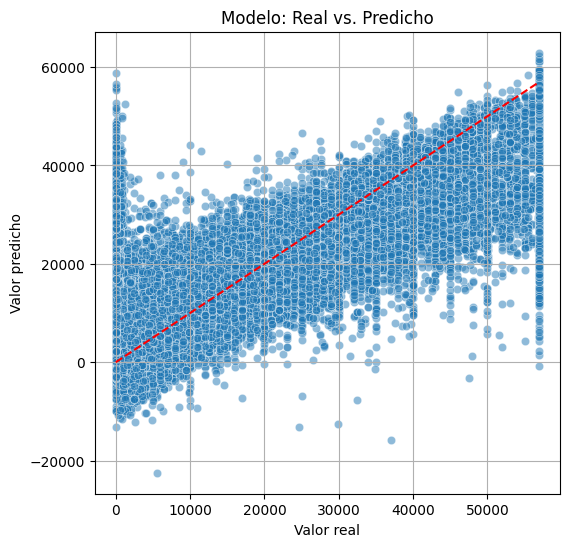

In [29]:
evaluar_regresion(ridge_grid.best_estimator_, X_test_reg, y_test_reg)

El gráfico muestra una tendencia alineada con la diagonal, lo que indica un ajuste razonable aunque con cierta dispersión en valores altos y bajos.  

- **MAE:** 5,241.97  
- **RMSE:** 8,224.76  
- **R²:** 0.664  

En conjunto, el modelo logra capturar parte importante de la variabilidad del precio, aunque aún presenta errores moderados.


📊 Evaluación del modelo de regresión: Modelo
→ MAE:  7352.21
→ RMSE: 10440.19
→ R²:   0.458


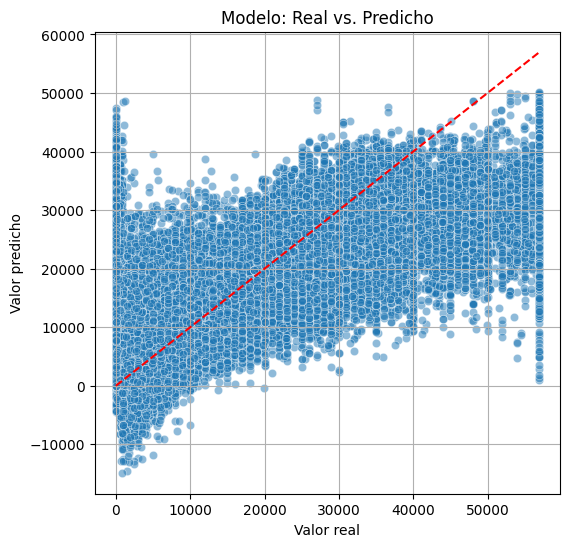

In [34]:
evaluar_regresion(lasso_grid.best_estimator_, X_test_reg, y_test_reg)

El modelo **Lasso** muestra un ajuste limitado entre los valores reales y predichos del `precio`.  
Aunque sigue la tendencia general (a mayor valor real, mayor predicción), existe una **alta dispersión** en los puntos, especialmente en los precios bajos y altos.  
Esto se refleja en las métricas:  

- **MAE:** 7,352.21 → error medio por predicción relativamente alto.  
- **RMSE:** 10,440.19 → indica que existen errores grandes en algunos casos.  
- **R²:** 0.458 → el modelo explica solo el 45.8% de la variabilidad en el precio.  


📊 Evaluación del modelo de clasificación: Logistic Regression
→ Accuracy:  0.862
→ Precision: 0.863
→ Recall:    0.862
→ F1-Score:  0.862
→ AUC:       0.938


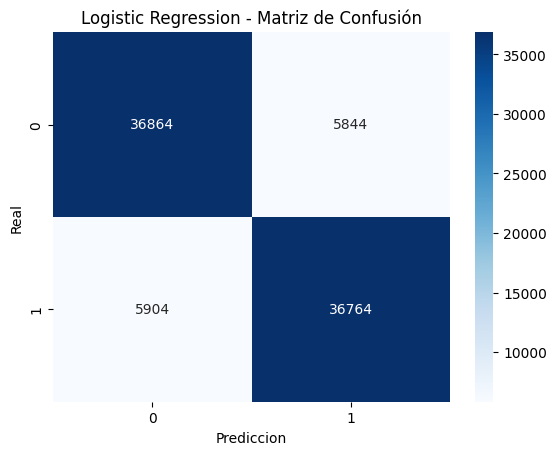

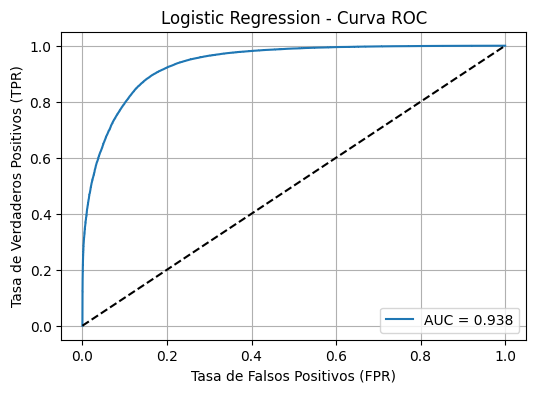

In [32]:
evaluar_clasificacion(logreg_grid.best_estimator_, X_test_clf, y_test_clf, "Logistic Regression")


El modelo de **Regresión Logística** presenta un desempeño sólido en la clasificación binaria.  

Métricas principales
- **Accuracy:** 0.862 → el 86.2% de las predicciones fueron correctas.  
- **Precision:** 0.863 → cuando el modelo predice clase positiva (1), acierta el 86.3% de las veces.  
- **Recall:** 0.862 → detecta correctamente el 86.2% de los casos positivos reales.  
- **F1-Score:** 0.862 → balance adecuado entre precisión y recall.  
- **AUC:** 0.938 → excelente capacidad de discriminación entre clases.  

La Matriz de confusión
- **Verdaderos Negativos (36864):** casos clase 0 bien clasificados.  
- **Falsos Positivos (5844):** casos clase 0 mal clasificados como 1.  
- **Falsos Negativos (5904):** casos clase 1 mal clasificados como 0.  
- **Verdaderos Positivos (36764):** casos clase 1 bien clasificados.  

La **curva ROC** (Receiver Operating Characteristic) muestra el desempeño del modelo de Regresión Logística al diferenciar entre las dos clases.  

- El eje **X** representa la **tasa de falsos positivos (FPR)**.  
- El eje **Y** representa la **tasa de verdaderos positivos (TPR o Recall)**.  
- La línea diagonal negra indica un **modelo aleatorio** (AUC = 0.5).  
- La curva azul se sitúa claramente por encima de esta línea, evidenciando un **buen poder de discriminación**.  